In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
from statistics import stdev
from scipy.stats import t

In [107]:
df=pd.read_csv('QVI_data.csv')
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


In [108]:
#Check the dataset for missing values in each column.
df.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [109]:
#Create a numeric year-month field and convert the DATE column to a datetime format.
df['YEARMONTH'] = [''.join(x.split('-')[0:2]) for x in df.DATE]
df['YEARMONTH'] = pd.to_numeric(df['YEARMONTH'])
df['YEARMONTH']

0         201810
1         201809
2         201903
3         201903
4         201811
           ...  
264829    201812
264830    201810
264831    201810
264832    201810
264833    201812
Name: YEARMONTH, Length: 264834, dtype: int64

In [110]:
# Total Sales for each store and month.
Total_Sales= df.groupby(['STORE_NBR', 'YEARMONTH']).TOT_SALES.sum()
Total_Sales

STORE_NBR  YEARMONTH
1          201807       206.9
           201808       176.1
           201809       278.8
           201810       188.1
           201811       192.6
                        ...  
272        201902       395.5
           201903       442.3
           201904       445.1
           201905       314.6
           201906       312.1
Name: TOT_SALES, Length: 3169, dtype: float64

In [111]:
# Number of customers for each store and month.
no_Customers = df.groupby(['STORE_NBR', 'YEARMONTH']).LYLTY_CARD_NBR.nunique()
no_Customers

STORE_NBR  YEARMONTH
1          201807       49
           201808       42
           201809       59
           201810       44
           201811       46
                        ..
272        201902       45
           201903       50
           201904       54
           201905       34
           201906       34
Name: LYLTY_CARD_NBR, Length: 3169, dtype: int64

In [112]:
# Transactions per customer for each store and month.
trans_per_customer = df.groupby(['STORE_NBR', 'YEARMONTH']).TXN_ID.nunique()/df.groupby(['STORE_NBR', 'YEARMONTH']).LYLTY_CARD_NBR.nunique()
trans_per_customer

STORE_NBR  YEARMONTH
1          201807       1.061224
           201808       1.023810
           201809       1.050847
           201810       1.022727
           201811       1.021739
                          ...   
272        201902       1.066667
           201903       1.060000
           201904       1.018519
           201905       1.176471
           201906       1.088235
Length: 3169, dtype: float64

In [113]:
# Chips per customer for each store and month.
chips_per_customer = df.groupby(['STORE_NBR', 'YEARMONTH']).PROD_QTY.sum()/ df.groupby(['STORE_NBR', 'YEARMONTH']).TXN_ID.nunique()
chips_per_customer

STORE_NBR  YEARMONTH
1          201807       1.192308
           201808       1.255814
           201809       1.209677
           201810       1.288889
           201811       1.212766
                          ...   
272        201902       1.895833
           201903       1.905660
           201904       1.909091
           201905       1.775000
           201906       1.891892
Length: 3169, dtype: float64

In [114]:
# Average price per unit for each store and month.
average_price = df.groupby(['STORE_NBR', 'YEARMONTH']).TOT_SALES.sum()/ df.groupby(['STORE_NBR', 'YEARMONTH']).PROD_QTY.sum()
average_price

STORE_NBR  YEARMONTH
1          201807       3.337097
           201808       3.261111
           201809       3.717333
           201810       3.243103
           201811       3.378947
                          ...   
272        201902       4.346154
           201903       4.379208
           201904       4.239048
           201905       4.430986
           201906       4.458571
Length: 3169, dtype: float64

In [115]:
# Concatenate into a new dataframe 'measureOverTime'
df2 = [Total_Sales, no_Customers, trans_per_customer, chips_per_customer, average_price]
measureOverTime = pd.concat(df2, join = 'outer', axis = 1)
measureOverTime

TOT_SALES  LYLTY_CARD_NBR         0         1         2
STORE_NBR YEARMONTH                                                         
1         201807         206.9              49  1.061224  1.192308  3.337097
          201808         176.1              42  1.023810  1.255814  3.261111
          201809         278.8              59  1.050847  1.209677  3.717333
          201810         188.1              44  1.022727  1.288889  3.243103
          201811         192.6              46  1.021739  1.212766  3.378947
...                        ...             ...       ...       ...       ...
272       201902         395.5              45  1.066667  1.895833  4.346154
          201903         442.3              50  1.060000  1.905660  4.379208
          201904         445.1              54  1.018519  1.909091  4.239048
          201905         314.6              34  1.176471  1.775000  4.430986
          201906         312.1              34  1.088235  1.891892  4.458571

[3169 rows x 5 columns]

In [116]:
# Rename the columns
measureOverTime.rename(columns = {'TOT_SALES': 'Total Sales', 'LYLTY_CARD_NBR': 'no_Customers', 0: 'trans_per_customer', 1: 'chips_per_customer', 2: 'average_price'}, inplace = True)
measureOverTime.head()

Total Sales  no_Customers  trans_per_customer  \
STORE_NBR YEARMONTH                                                  
1         201807           206.9            49            1.061224   
          201808           176.1            42            1.023810   
          201809           278.8            59            1.050847   
          201810           188.1            44            1.022727   
          201811           192.6            46            1.021739   

                     chips_per_customer  average_price  
STORE_NBR YEARMONTH                                     
1         201807               1.192308       3.337097  
          201808               1.255814       3.261111  
          201809               1.209677       3.717333  
          201810               1.288889       3.243103  
          201811               1.212766       3.378947

In [117]:
measureOverTime.reset_index(inplace = True)
measureOverTime

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947
...,...,...,...,...,...,...,...
3164,272,201902,395.5,45,1.066667,1.895833,4.346154
3165,272,201903,442.3,50,1.060000,1.905660,4.379208
3166,272,201904,445.1,54,1.018519,1.909091,4.239048
3167,272,201905,314.6,34,1.176471,1.775000,4.430986


In [118]:
#Create a transaction month column for time-based analysis and later comparisons.
measureOverTime['TransactionMonth'] = pd.to_datetime(measureOverTime['YEARMONTH'].astype(str), format = '%Y%m')
measureOverTime.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01


In [119]:
# Filter to the pre-trial period and stores with full observation periods
df2 = pd.pivot_table(df, index = 'STORE_NBR', columns = 'YEARMONTH', values = 'TXN_ID', aggfunc = 'count')
df2

YEARMONTH,201807,201808,201809,201810,201811,201812,201901,201902,201903,201904,201905,201906
STORE_NBR,,,,,,,,,,,,
1,52.0,43.0,62.0,45.0,47.0,47.0,36.0,55.0,49.0,43.0,51.0,43.0
2,41.0,43.0,37.0,43.0,40.0,38.0,45.0,32.0,46.0,49.0,50.0,42.0
3,138.0,134.0,119.0,119.0,118.0,129.0,121.0,139.0,130.0,110.0,123.0,122.0
4,160.0,151.0,138.0,155.0,139.0,133.0,168.0,102.0,135.0,137.0,126.0,134.0
5,120.0,112.0,125.0,107.0,111.0,125.0,118.0,106.0,97.0,109.0,104.0,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...
268,52.0,54.0,34.0,48.0,51.0,43.0,38.0,37.0,47.0,50.0,52.0,40.0
269,139.0,132.0,124.0,148.0,136.0,133.0,144.0,133.0,122.0,139.0,130.0,127.0
270,139.0,154.0,126.0,119.0,133.0,149.0,155.0,125.0,143.0,132.0,128.0,127.0


In [120]:
# Store numbers that do not have full observation periods
null_stores = df2[df2.isnull().any(axis=1)].index.tolist()
null_stores

[11, 31, 44, 76, 85, 92, 117, 193, 206, 211, 218, 252]

In [121]:
# Filter out the null stores
measureOverTime = measureOverTime[~measureOverTime['STORE_NBR'].isin(null_stores)]
measureOverTime

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01
...,...,...,...,...,...,...,...,...
3164,272,201902,395.5,45,1.066667,1.895833,4.346154,2019-02-01
3165,272,201903,442.3,50,1.060000,1.905660,4.379208,2019-03-01
3166,272,201904,445.1,54,1.018519,1.909091,4.239048,2019-04-01
3167,272,201905,314.6,34,1.176471,1.775000,4.430986,2019-05-01


In [122]:
# Filter to pre-trial period before 201902
preTrialMeasures = measureOverTime[measureOverTime['YEARMONTH'] < 201902]
preTrialMeasures

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01
...,...,...,...,...,...,...,...,...
3159,272,201809,304.7,32,1.125000,1.972222,4.291549,2018-09-01
3160,272,201810,430.6,44,1.136364,1.980000,4.349495,2018-10-01
3161,272,201811,376.2,41,1.097561,1.933333,4.324138,2018-11-01
3162,272,201812,403.9,47,1.000000,1.893617,4.538202,2018-12-01


In [123]:
#### Create a function to calculate correlation for a measure

def calculateCorrelation(inputTable, metricCol, trial_store):
  records = []
  x = (
      inputTable.loc[inputTable['STORE_NBR'] == trial_store, metricCol]
      .reset_index(drop=True)
  )
  storeNumbers = inputTable['STORE_NBR'].unique()
  for i in storeNumbers:
    y = (
        inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        .reset_index(drop=True)
    )
    records.append(
        {'Store1': trial_store, 'Store2': i, 'corr_measure': y.corr(x)}
    )
  return pd.DataFrame(records)

In [124]:
#Define a function to calculate the magnitude distance between a trial store and potential control stores.
def calculateMagnitudeDistance(inputTable, metricCol, trial_store):
  records = []
  x = (
      inputTable.loc[inputTable['STORE_NBR'] == trial_store, metricCol]
      .reset_index(drop=True)
  )
  storeNumbers = inputTable['STORE_NBR'].unique()
  for i in storeNumbers:
    y = (
        inputTable.loc[inputTable['STORE_NBR'] == i, metricCol]
        .reset_index(drop=True)
    )
    z = abs(x - y)

    if max(z) - min(z) == 0:
      A = 1.0
    else:
      A = np.mean(1 - (z - min(z)) / (max(z) - min(z)))
    records.append({'Store1': trial_store, 'Store2': i, 'Magnitude': A})
  return pd.DataFrame(records)

In [125]:
#Select trial store 77 and calculate its sales and customer similarity scores.
trial_store = 77
corr_Sales = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store)
corr_Customers = calculateCorrelation(
    preTrialMeasures, 'no_Customers', trial_store
)

magnitude_Sales = calculateMagnitudeDistance(
    preTrialMeasures, 'Total Sales', trial_store
)
magnitude_Customers = calculateMagnitudeDistance(
    preTrialMeasures, 'no_Customers', trial_store
)

In [126]:
#Combine the sales correlation and magnitude results into one scoring table
score_Sales = pd.concat([corr_Sales, magnitude_Sales['Magnitude']], axis = 1)
score_Sales

,Store1,Store2,corr_measure,Magnitude
0,77,1,0.075218,0.408163
1,77,2,-0.263079,0.590119
2,77,3,0.806644,0.522914
3,77,4,-0.263300,0.644934
4,77,5,-0.110652,0.516320
...,...,...,...,...
255,77,268,0.344757,0.429787
256,77,269,-0.315730,0.559099
257,77,270,0.315430,0.591547
258,77,271,0.355487,0.341091


In [127]:
#Combine the customer correlation and magnitude results into one scoring table.
score_Customers = pd.concat([corr_Customers, magnitude_Customers['Magnitude']], axis = 1)
score_Customers

,Store1,Store2,corr_measure,Magnitude
0,77,1,0.322168,0.663866
1,77,2,-0.572051,0.471429
2,77,3,0.834207,0.489796
3,77,4,-0.295639,0.498258
4,77,5,0.370659,0.512605
...,...,...,...,...
255,77,268,0.369517,0.571429
256,77,269,-0.474293,0.484472
257,77,270,-0.131259,0.536680
258,77,271,0.019629,0.328571


In [128]:
# Add an additional column which calculates the weighted average
corr_weight = 0.5
score_Sales['scoreSales'] = corr_weight * score_Sales['corr_measure'] + (1 - corr_weight) * score_Sales['Magnitude']
score_Customers['scoreCustomers'] = corr_weight * score_Customers['corr_measure'] + (1 - corr_weight) * score_Customers['Magnitude']

In [129]:
#Reset the indexes so the scoring tables can be filtered and compared correctly.
score_Sales = score_Sales.reset_index()
score_Customers = score_Customers.reset_index()

score_Sales.set_index(['Store1', 'Store2'], inplace=True)
score_Customers.set_index(['Store1', 'Store2'], inplace=True)

score_Control = pd.concat(
    [score_Sales['scoreSales'], score_Customers['scoreCustomers']], axis=1
)

score_Control['finalControlScore'] = (
    0.5 * score_Control['scoreSales'] + 0.5 * score_Control['scoreCustomers']
)

control_store_77 = score_Control.reset_index()
control_store_77 = control_store_77[
    control_store_77['Store2'] != trial_store
].sort_values(by='finalControlScore', ascending=False)

control_store_77.head()

,Store1,Store2,scoreSales,scoreCustomers,finalControlScore
221,77,233,0.697290,0.816607,0.756949
67,77,71,0.789497,0.663123,0.726310
79,77,84,0.656972,0.715000,0.685986
111,77,119,0.636046,0.729729,0.682887
108,77,115,0.708347,0.645155,0.676751


In [130]:
#Classify stores as Trial Store, Control Store, or Other Store using the selected control store.
control_store = 233

pastSales = preTrialMeasures

store_type = []

for i in pastSales['STORE_NBR']:
    if i == trial_store:
        store_type.append('Trial Store')
    elif i == control_store:
        store_type.append('Control Store')
    else:
        store_type.append('Other Stores')

pastSales['store_type'] = store_type
pastSales.head()

C:\Users\HELAL\AppData\Local\Temp\ipykernel_20488\2415786882.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pastSales['store_type'] = store_type


,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,store_type
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01,Other Stores
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01,Other Stores
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01,Other Stores
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01,Other Stores
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01,Other Stores


In [131]:
#Create a datetime month field and prepare the historical sales data for plotting.
pastSales['TransactionMonth'] = pd.to_datetime(pastSales['YEARMONTH'].astype(str), format = '%Y%m')
pastSales['TransactionMonth']

C:\Users\HELAL\AppData\Local\Temp\ipykernel_20488\422660888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pastSales['TransactionMonth'] = pd.to_datetime(pastSales['YEARMONTH'].astype(str), format = '%Y%m')


0      2018-07-01
1      2018-08-01
2      2018-09-01
3      2018-10-01
4      2018-11-01
          ...    
3159   2018-09-01
3160   2018-10-01
3161   2018-11-01
3162   2018-12-01
3163   2019-01-01
Name: TransactionMonth, Length: 1820, dtype: datetime64[ns]

In [132]:
#Create short month labels to make the time-series charts easier to read.
pastSales['Month'] = pd.DatetimeIndex(pastSales['TransactionMonth']).month_name().str[:3]
pastSales

C:\Users\HELAL\AppData\Local\Temp\ipykernel_20488\3082946159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pastSales['Month'] = pd.DatetimeIndex(pastSales['TransactionMonth']).month_name().str[:3]


,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,store_type,Month
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01,Other Stores,Jul
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01,Other Stores,Aug
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01,Other Stores,Sep
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01,Other Stores,Oct
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01,Other Stores,Nov
...,...,...,...,...,...,...,...,...,...,...
3159,272,201809,304.7,32,1.125000,1.972222,4.291549,2018-09-01,Other Stores,Sep
3160,272,201810,430.6,44,1.136364,1.980000,4.349495,2018-10-01,Other Stores,Oct
3161,272,201811,376.2,41,1.097561,1.933333,4.324138,2018-11-01,Other Stores,Nov
3162,272,201812,403.9,47,1.000000,1.893617,4.538202,2018-12-01,Other Stores,Dec


In [133]:
#Prepare the control-store monthly sales data for comparison with the trial store.
controlPlot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot.set_index('Month', inplace = True)

trialPlot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot.set_index('Month', inplace = True)

otherPlot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot = pd.DataFrame(otherPlot.groupby('Month')['Total Sales'].mean())

controlPlot.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

combinePlot = pd.concat([controlPlot, trialPlot, otherPlot], axis = 1)

combinePlot

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,290.7,296.8,638.004651
Aug,285.9,255.5,610.223450
Sep,228.6,225.2,620.198450
Oct,185.7,204.5,635.314729
Nov,211.6,245.3,618.864341
Dec,279.8,267.3,648.453876
Jan,177.5,204.4,628.684496


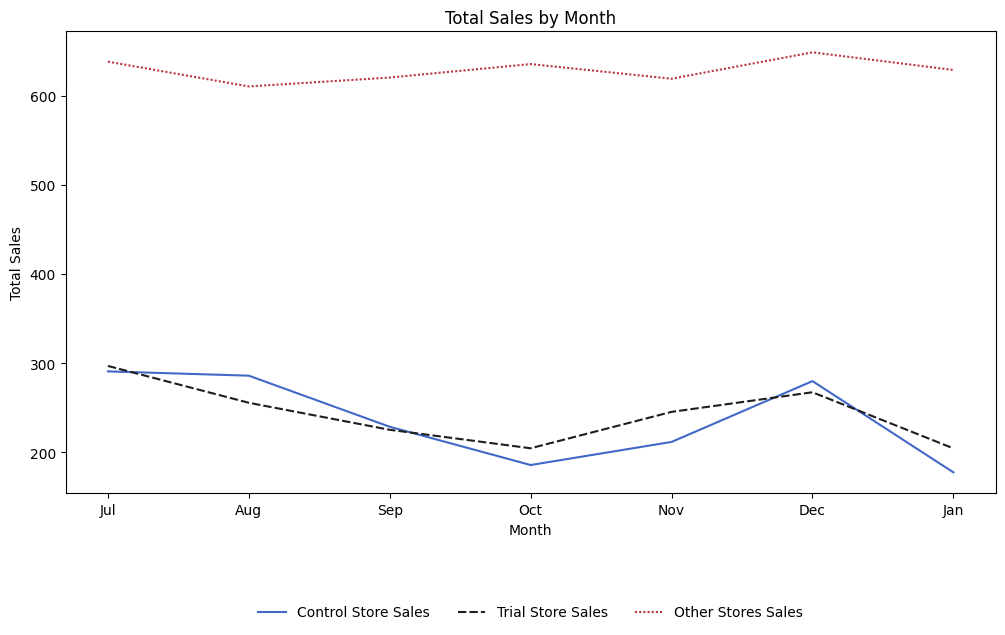

In [134]:
# Plot total Sales for all 3 types of stores
plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month')
ax = sns.lineplot(data=combinePlot, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

In [135]:
#Prepare the control-store monthly customer data for comparison with the trial store.
control_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot.set_index('Month', inplace = True)

trial_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot.set_index('Month', inplace = True)

other_Customer_Plot = pastSales.loc[pastSales['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot = pd.DataFrame(other_Customer_Plot.groupby('Month')['no_Customers'].mean())

control_Customer_Plot.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

combine_Customer_Plot = pd.concat([control_Customer_Plot, trial_Customer_Plot, other_Customer_Plot], axis = 1)

combine_Customer_Plot

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,51,51,72.333333
Aug,48,47,72.120155
Sep,42,42,70.131783
Oct,35,37,71.608527
Nov,40,41,70.534884
Dec,47,46,73.515504
Jan,35,35,71.240310


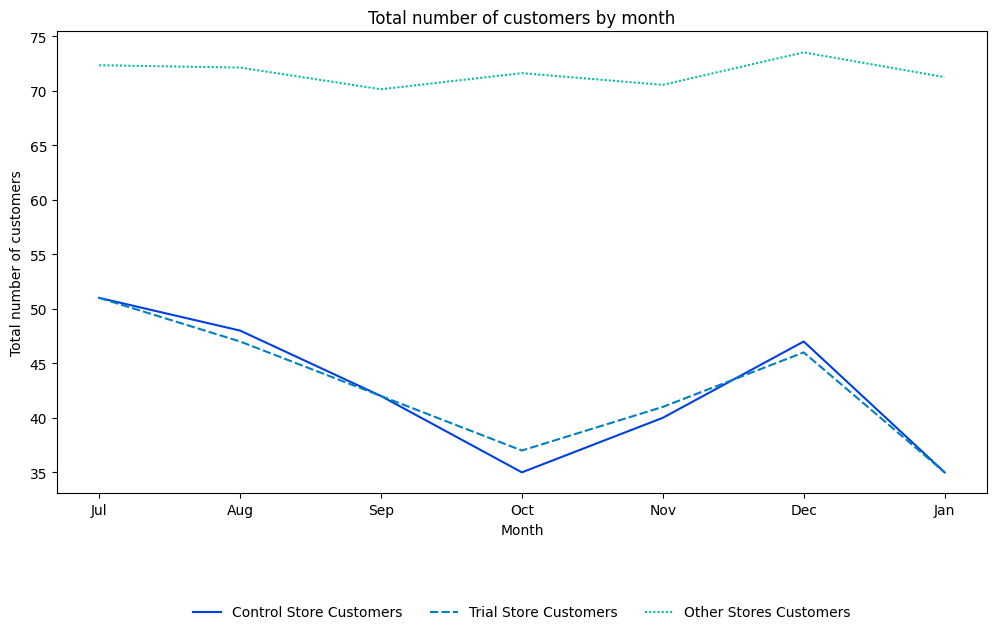

In [136]:
# Plot total number of customers for all 3 types of stores
plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month')
ax1 = sns.lineplot(data=combine_Customer_Plot, palette="winter")

plt.ylabel("Total number of customers")
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

In [137]:
#Display the pre-trial measures used for the control-store analysis.
preTrialMeasures

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,store_type,Month
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01,Other Stores,Jul
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01,Other Stores,Aug
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01,Other Stores,Sep
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01,Other Stores,Oct
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01,Other Stores,Nov
...,...,...,...,...,...,...,...,...,...,...
3159,272,201809,304.7,32,1.125000,1.972222,4.291549,2018-09-01,Other Stores,Sep
3160,272,201810,430.6,44,1.136364,1.980000,4.349495,2018-10-01,Other Stores,Oct
3161,272,201811,376.2,41,1.097561,1.933333,4.324138,2018-11-01,Other Stores,Nov
3162,272,201812,403.9,47,1.000000,1.893617,4.538202,2018-12-01,Other Stores,Dec


In [138]:
# Scale pre-trial control sales to match pre-trial trial store sales
trial_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales = trial_sales_sum/ control_sales_sum
scalingFactorForControlSales

np.float64(1.023617303289553)

In [139]:
# Apply the scaling factor
measureOverTimeSales = measureOverTime
scaledControlSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store]
scaledControlSales['controlSales'] = scaledControlSales['Total Sales'] * scalingFactorForControlSales
scaledControlSales

C:\Users\HELAL\AppData\Local\Temp\ipykernel_20488\3157655149.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaledControlSales['controlSales'] = scaledControlSales['Total Sales'] * scalingFactorForControlSales


,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
2699,233,201807,290.7,51,1.058824,1.629630,3.303409,2018-07-01,297.565550
2700,233,201808,285.9,48,1.041667,1.600000,3.573750,2018-08-01,292.652187
2701,233,201809,228.6,42,1.071429,1.555556,3.265714,2018-09-01,233.998916
2702,233,201810,185.7,35,1.028571,1.555556,3.316071,2018-10-01,190.085733
2703,233,201811,211.6,40,1.025000,1.512195,3.412903,2018-11-01,216.597421
2704,233,201812,279.8,47,1.063830,1.500000,3.730667,2018-12-01,286.408121
2705,233,201901,177.5,35,1.000000,1.342857,3.776596,2019-01-01,181.692071
2706,233,201902,244.0,45,1.044444,1.489362,3.485714,2019-02-01,249.762622
2707,233,201903,199.1,40,1.025000,1.439024,3.374576,2019-03-01,203.802205
2708,233,201904,158.6,30,1.066667,1.437500,3.447826,2019-04-01,162.345704


In [140]:
# Add a new column 'TransactionMonth' to 'scaledControlSales'
scaledControlSales['TransactionMonth'] = pd.to_datetime(scaledControlSales['YEARMONTH'].astype(str), format = '%Y%m')
scaledControlSales

C:\Users\HELAL\AppData\Local\Temp\ipykernel_20488\3869168429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaledControlSales['TransactionMonth'] = pd.to_datetime(scaledControlSales['YEARMONTH'].astype(str), format = '%Y%m')


,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
2699,233,201807,290.7,51,1.058824,1.629630,3.303409,2018-07-01,297.565550
2700,233,201808,285.9,48,1.041667,1.600000,3.573750,2018-08-01,292.652187
2701,233,201809,228.6,42,1.071429,1.555556,3.265714,2018-09-01,233.998916
2702,233,201810,185.7,35,1.028571,1.555556,3.316071,2018-10-01,190.085733
2703,233,201811,211.6,40,1.025000,1.512195,3.412903,2018-11-01,216.597421
2704,233,201812,279.8,47,1.063830,1.500000,3.730667,2018-12-01,286.408121
2705,233,201901,177.5,35,1.000000,1.342857,3.776596,2019-01-01,181.692071
2706,233,201902,244.0,45,1.044444,1.489362,3.485714,2019-02-01,249.762622
2707,233,201903,199.1,40,1.025000,1.439024,3.374576,2019-03-01,203.802205
2708,233,201904,158.6,30,1.066667,1.437500,3.447826,2019-04-01,162.345704


In [141]:
#Create a table containing trial-store sales and scaled control-store sales.
percentageDiff = scaledControlSales[['YEARMONTH','controlSales']]
percentageDiff.reset_index(drop = True, inplace = True)
trial_sales = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store , 'Total Sales']
trial_sales.reset_index(drop = True, inplace = True)

percentageDiff = pd.concat([percentageDiff, trial_sales], axis = 1)
percentageDiff.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff

,YEARMONTH,controlSales,Trial_Sales
0,201807,297.565550,296.8
1,201808,292.652187,255.5
2,201809,233.998916,225.2
3,201810,190.085733,204.5
4,201811,216.597421,245.3
5,201812,286.408121,267.3
6,201901,181.692071,204.4
7,201902,249.762622,235.0
8,201903,203.802205,278.5
9,201904,162.345704,263.5


In [142]:
#Calculate the absolute percentage difference between trial and control sales.
percentageDiff['percentageDiff'] = abs(percentageDiff.controlSales - percentageDiff.Trial_Sales) / percentageDiff.controlSales
percentageDiff

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,297.565550,296.8,0.002573
1,201808,292.652187,255.5,0.126950
2,201809,233.998916,225.2,0.037602
3,201810,190.085733,204.5,0.075830
4,201811,216.597421,245.3,0.132516
5,201812,286.408121,267.3,0.066716
6,201901,181.692071,204.4,0.124980
7,201902,249.762622,235.0,0.059107
8,201903,203.802205,278.5,0.366521
9,201904,162.345704,263.5,0.623080


In [143]:
#Calculate the pre-trial standard deviation of the sales percentage differences.
from statistics import stdev
stdDev = stdev(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev

0.049940762641425364

In [144]:
#Calculate t-values for the sales differences and identify statistically significant periods.
percentageDiff['tValue'] = (percentageDiff['percentageDiff'] - 0) / stdDev
percentageDiff.loc[(percentageDiff['YEARMONTH'] < 201905 ) & (percentageDiff['YEARMONTH'] > 201901), 'tValue']

7     1.183534
8     7.339116
9    12.476373
Name: tValue, dtype: float64

In [145]:
#Set the degrees of freedom based on the number of pre-trial observations.
degreesOfFreedom = len(percentageDiff.loc[percentageDiff['YEARMONTH'] < 201902]) - 1

In [146]:
#Calculate the 95% critical value from the t-distribution.
t95 = t.isf(0.05, degreesOfFreedom)
print('95th percentile of the t distribution with the degrees Of Freedom ' + str(degreesOfFreedom) + '   -', t95)

95th percentile of the t distribution with the degrees Of Freedom 6   - 1.943180280515305


In [147]:
#Prepare the trial-store sales data for comparison with the scaled control sales.
pastSales = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store, ['TransactionMonth', 'Total Sales']]
pastSales.set_index('TransactionMonth', inplace = True)
pastSales.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)
pastSales

,Trial Sales
TransactionMonth,
2018-07-01,296.8
2018-08-01,255.5
2018-09-01,225.2
2018-10-01,204.5
2018-11-01,245.3
2018-12-01,267.3
2019-01-01,204.4
2019-02-01,235.0
2019-03-01,278.5


In [148]:
#Prepare the scaled control-store sales data for the confidence-interval calculation.
controlSales = scaledControlSales.loc[:, ['TransactionMonth', 'controlSales']]
controlSales.set_index('TransactionMonth', inplace = True)
controlSales.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)
controlSales

,Control Sales
TransactionMonth,
2018-07-01,297.565550
2018-08-01,292.652187
2018-09-01,233.998916
2018-10-01,190.085733
2018-11-01,216.597421
2018-12-01,286.408121
2019-01-01,181.692071
2019-02-01,249.762622
2019-03-01,203.802205


In [149]:
#Calculate the upper 95% confidence boundary for the control-store sales.
controlSales['Control store 95th percentile'] = controlSales['Control Sales'] * (1 + stdDev*2)
controlSales['Control store 5th percentile'] = controlSales['Control Sales'] * (1 - stdDev*2)
controlSales

,Control Sales,Control store 95th percentile,Control store 5th percentile
TransactionMonth,,,
2018-07-01,297.565550,327.286851,267.844249
2018-08-01,292.652187,321.882734,263.421640
2018-09-01,233.998916,257.371084,210.626747
2018-10-01,190.085733,209.071786,171.099680
2018-11-01,216.597421,238.231502,194.963341
2018-12-01,286.408121,315.015001,257.801241
2019-01-01,181.692071,199.839753,163.544390
2019-02-01,249.762622,274.709294,224.815950
2019-03-01,203.802205,224.158280,183.446130


In [150]:
#Combine trial and control sales into a single assessment dataframe.
trialAssessment = pd.merge(controlSales, pastSales, left_index = True, right_index = True)
trialAssessment

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,297.565550,327.286851,267.844249,296.8
2018-08-01,292.652187,321.882734,263.421640,255.5
2018-09-01,233.998916,257.371084,210.626747,225.2
2018-10-01,190.085733,209.071786,171.099680,204.5
2018-11-01,216.597421,238.231502,194.963341,245.3
2018-12-01,286.408121,315.015001,257.801241,267.3
2019-01-01,181.692071,199.839753,163.544390,204.4
2019-02-01,249.762622,274.709294,224.815950,235.0
2019-03-01,203.802205,224.158280,183.446130,278.5


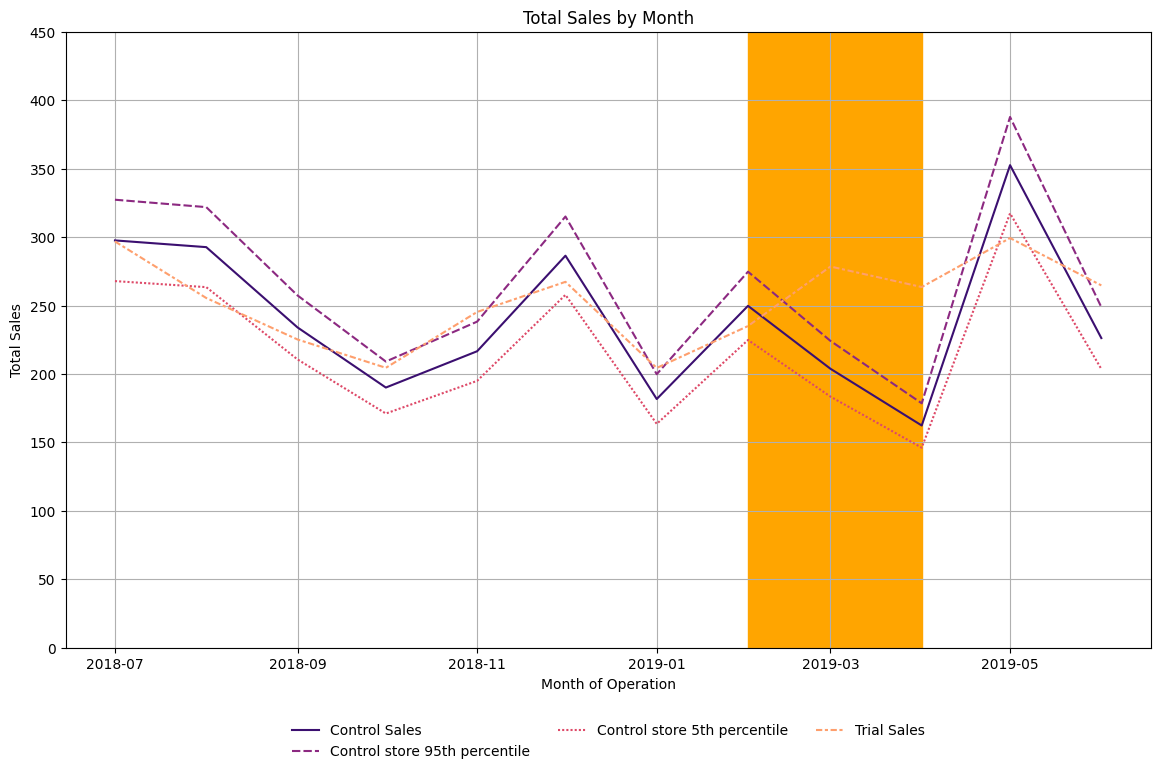

In [151]:
#Plot trial-store sales against scaled control sales and the confidence boundary.
plt.figure(figsize = (14,8))
ax2 = sns.lineplot(data=trialAssessment, palette = 'magma')

sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)
plt.title('Total Sales by Month')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.ylim((0, 450))
plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

In [152]:
# Scale pre-trial control customers to match pre-trial trial store customers
trial_customers_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers_sum = preTrialMeasures.loc[preTrialMeasures['store_type'] == 'Control Store' , 'no_Customers'].sum()
scalingFactorForControlCustomers = trial_customers_sum/ control_customers_sum
scalingFactorForControlCustomers

np.float64(1.0033557046979866)

In [153]:
# Apply the scaling factor
scaledControlCustomers = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store].copy()
scaledControlCustomers['controlCustomers'] = scaledControlCustomers['no_Customers'] * scalingFactorForControlCustomers
scaledControlCustomers['TransactionMonth'] = pd.to_datetime(scaledControlCustomers['YEARMONTH'].astype(str), format = '%Y%m')
scaledControlCustomers

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlCustomers
2699,233,201807,290.7,51,1.058824,1.629630,3.303409,2018-07-01,51.171141
2700,233,201808,285.9,48,1.041667,1.600000,3.573750,2018-08-01,48.161074
2701,233,201809,228.6,42,1.071429,1.555556,3.265714,2018-09-01,42.140940
2702,233,201810,185.7,35,1.028571,1.555556,3.316071,2018-10-01,35.117450
2703,233,201811,211.6,40,1.025000,1.512195,3.412903,2018-11-01,40.134228
2704,233,201812,279.8,47,1.063830,1.500000,3.730667,2018-12-01,47.157718
2705,233,201901,177.5,35,1.000000,1.342857,3.776596,2019-01-01,35.117450
2706,233,201902,244.0,45,1.044444,1.489362,3.485714,2019-02-01,45.151007
2707,233,201903,199.1,40,1.025000,1.439024,3.374576,2019-03-01,40.134228
2708,233,201904,158.6,30,1.066667,1.437500,3.447826,2019-04-01,30.100671


In [154]:
#Create a table comparing trial and scaled control customer counts.
percentageDiffCustomers = scaledControlCustomers[['YEARMONTH','controlCustomers']]
percentageDiffCustomers.reset_index(drop = True, inplace = True)
trial_customers = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store , 'no_Customers']
trial_customers.reset_index(drop = True, inplace = True)

percentageDiffCustomers = pd.concat([percentageDiffCustomers, trial_customers], axis = 1)
percentageDiffCustomers.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiffCustomers['percentageDiff'] = abs(percentageDiffCustomers.controlCustomers - percentageDiffCustomers.Trial_Customers) / percentageDiffCustomers.controlCustomers
percentageDiffCustomers

,YEARMONTH,controlCustomers,Trial_Customers,percentageDiff
0,201807,51.171141,51,0.003344
1,201808,48.161074,47,0.024108
2,201809,42.140940,42,0.003344
3,201810,35.117450,37,0.053607
4,201811,40.134228,41,0.021572
5,201812,47.157718,46,0.024550
6,201901,35.117450,35,0.003344
7,201902,45.151007,45,0.003344
8,201903,40.134228,50,0.245819
9,201904,30.100671,47,0.561427


In [155]:
#Calculate the pre-trial standard deviation of customer percentage differences.
stdDevCustomers = stdev(percentageDiffCustomers.loc[percentageDiffCustomers['YEARMONTH'] < 201902, 'percentageDiff'])
stdDevCustomers

0.018240748558243945

In [156]:
#Calculate t-values for customer differences and identify statistically significant periods.
percentageDiffCustomers['tValue'] = (percentageDiffCustomers['percentageDiff'] - 0) / stdDevCustomers
percentageDiffCustomers.loc[(percentageDiffCustomers['YEARMONTH'] < 201905 ) & (percentageDiffCustomers['YEARMONTH'] > 201901), 'tValue']

7     0.183352
8    13.476388
9    30.778725
Name: tValue, dtype: float64

In [157]:
#Prepare the trial-store customer data for comparison with the scaled control customers.
trialCustomersOnly = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store, ['TransactionMonth', 'no_Customers']]
trialCustomersOnly.set_index('TransactionMonth', inplace = True)
trialCustomersOnly.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)

controlCustomersOnly = scaledControlCustomers.loc[:, ['TransactionMonth', 'controlCustomers']]
controlCustomersOnly.set_index('TransactionMonth', inplace = True)
controlCustomersOnly.rename(columns = {'controlCustomers': 'Control Customers'}, inplace = True)

#### Control store 95th / 5th percentile
controlCustomersOnly['Control store 95th percentile'] = controlCustomersOnly['Control Customers'] * (1 + stdDevCustomers*2)
controlCustomersOnly['Control store 5th percentile'] = controlCustomersOnly['Control Customers'] * (1 - stdDevCustomers*2)

customerAssessment = pd.merge(controlCustomersOnly, trialCustomersOnly, left_index = True, right_index = True)
customerAssessment

,Control Customers,Control store 95th percentile,Control store 5th percentile,Trial Customers
TransactionMonth,,,,
2018-07-01,51.171141,53.037941,49.304341,51
2018-08-01,48.161074,49.918062,46.404086,47
2018-09-01,42.140940,43.678304,40.603575,42
2018-10-01,35.117450,36.398587,33.836313,37
2018-11-01,40.134228,41.598385,38.670071,41
2018-12-01,47.157718,48.878102,45.437334,46
2019-01-01,35.117450,36.398587,33.836313,35
2019-02-01,45.151007,46.798183,43.503830,45
2019-03-01,40.134228,41.598385,38.670071,50


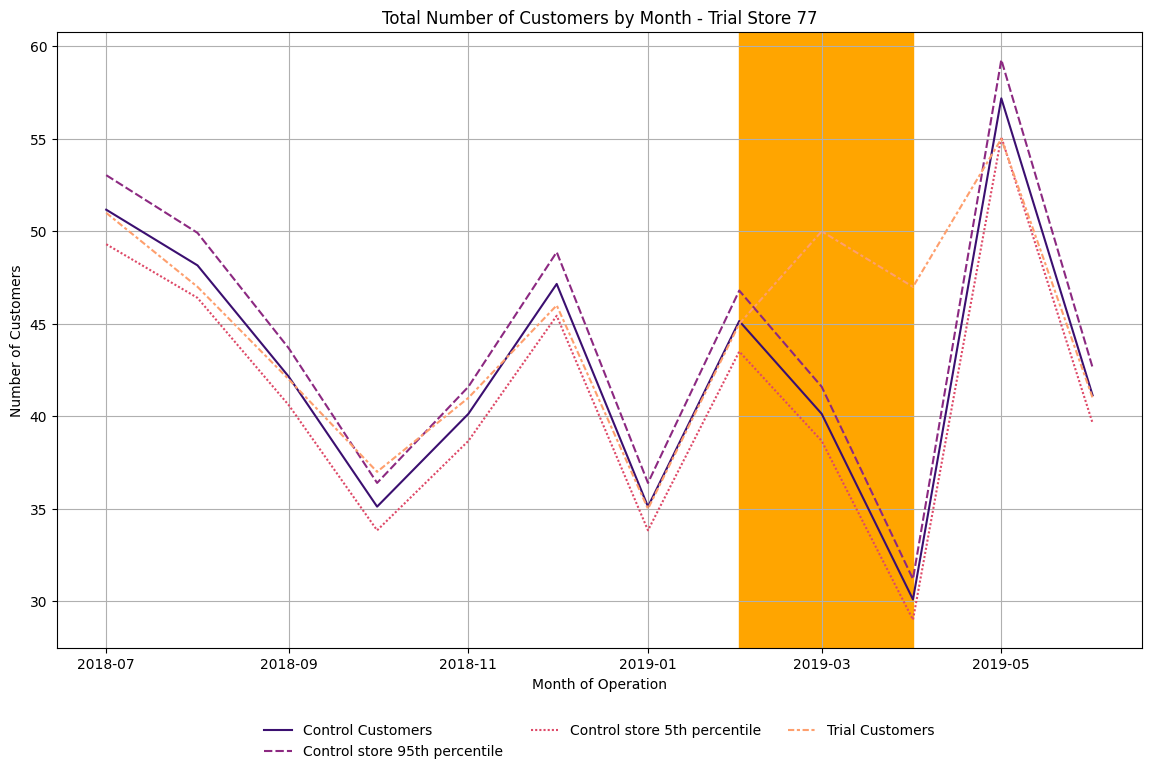

In [158]:
#Plot trial-store customers against scaled control customers and the confidence boundary.
plt.figure(figsize = (14,8))
ax3 = sns.lineplot(data=customerAssessment, palette = 'magma')

sns.move_legend(
    ax3, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month - Trial Store 77')
plt.xlabel('Month of Operation')
plt.ylabel('Number of Customers')

plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

In [159]:
#Select trial store 86 and calculate sales and customer similarity scores.
trial_store_86 = 86
corr_Sales_86 = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store_86)
corr_Customers_86 = calculateCorrelation(preTrialMeasures, 'no_Customers', trial_store_86)

magnitude_Sales_86 = calculateMagnitudeDistance(preTrialMeasures, 'Total Sales', trial_store_86)
magnitude_Customers_86 = calculateMagnitudeDistance(preTrialMeasures, 'no_Customers', trial_store_86)

In [160]:
#Combine the sales and customer correlation and magnitude scores for trial store 86.
score_Sales_86 = pd.concat([corr_Sales_86, magnitude_Sales_86['Magnitude']], axis = 1)
score_Customers_86 = pd.concat([corr_Customers_86, magnitude_Customers_86['Magnitude']], axis = 1)

score_Sales_86['scoreSales'] = corr_weight * score_Sales_86['corr_measure'] + (1 - corr_weight) * score_Sales_86['Magnitude']
score_Customers_86['scoreCustomers'] = corr_weight * score_Customers_86['corr_measure'] + (1 - corr_weight) * score_Customers_86['Magnitude']

score_Sales_86 = score_Sales_86.reset_index().set_index(['Store1', 'Store2'])
score_Customers_86 = score_Customers_86.reset_index().set_index(['Store1', 'Store2'])

score_Control_86 = pd.concat([score_Sales_86['scoreSales'], score_Customers_86['scoreCustomers']], axis=1)
score_Control_86['finalControlScore'] = 0.5 * score_Control_86['scoreSales'] + 0.5 * score_Control_86['scoreCustomers']

control_store_86_candidates = score_Control_86.reset_index()
control_store_86_candidates = control_store_86_candidates[
    control_store_86_candidates['Store2'] != trial_store_86
].sort_values(by='finalControlScore', ascending=False)

control_store_86_candidates.head()

,Store1,Store2,scoreSales,scoreCustomers,finalControlScore
147,86,155,0.808106,0.733343,0.770724
102,86,109,0.697120,0.742532,0.719826
107,86,114,0.631393,0.663384,0.647389
213,86,225,0.601841,0.684356,0.643099
130,86,138,0.593296,0.660565,0.626930


In [161]:
#Select the best matching control store for trial store 86.
control_store_86 = int(control_store_86_candidates.iloc[0]['Store2'])
control_store_86

155

In [162]:
#Classify stores for the trial-store-86 analysis and prepare the historical data.
pastSales_86 = preTrialMeasures.copy()
store_type_86 = []
for i in pastSales_86['STORE_NBR']:
    if i == trial_store_86:
        store_type_86.append('Trial Store')
    elif i == control_store_86:
        store_type_86.append('Control Store')
    else:
        store_type_86.append('Other Stores')

pastSales_86['store_type'] = store_type_86
pastSales_86['TransactionMonth'] = pd.to_datetime(pastSales_86['YEARMONTH'].astype(str), format = '%Y%m')
pastSales_86['Month'] = pd.DatetimeIndex(pastSales_86['TransactionMonth']).month_name().str[:3]
pastSales_86.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,store_type,Month
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01,Other Stores,Jul
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01,Other Stores,Aug
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01,Other Stores,Sep
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01,Other Stores,Oct
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01,Other Stores,Nov


In [163]:
#Prepare monthly sales data for the control store matched to trial store 86.
controlPlot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot_86.set_index('Month', inplace = True)

trialPlot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot_86.set_index('Month', inplace = True)

otherPlot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot_86 = pd.DataFrame(otherPlot_86.groupby('Month')['Total Sales'].mean())

controlPlot_86.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot_86.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot_86.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

combinePlot_86 = pd.concat([controlPlot_86, trialPlot_86, otherPlot_86], axis = 1)
combinePlot_86

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,924.6,892.20,633.239922
Aug,782.7,764.05,606.326744
Sep,1014.4,914.60,614.480620
Oct,963.8,948.40,629.415504
Nov,898.8,918.00,613.593411
Dec,849.8,841.20,644.020155
Jan,874.6,841.40,623.513566


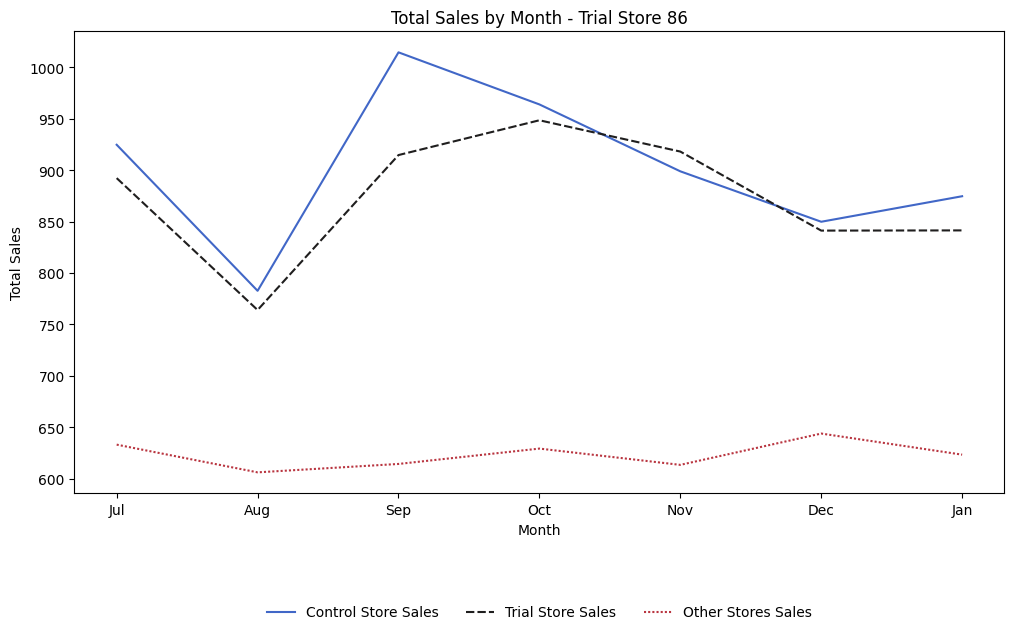

In [164]:
#Plot monthly sales for trial store 86 and its selected control store.ر
plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month - Trial Store 86')
ax_86 = sns.lineplot(data=combinePlot_86, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax_86, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

In [165]:
#Prepare monthly customer data for the control store matched to trial store 86.
control_Customer_Plot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot_86.set_index('Month', inplace = True)

trial_Customer_Plot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot_86.set_index('Month', inplace = True)

other_Customer_Plot_86 = pastSales_86.loc[pastSales_86['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot_86 = pd.DataFrame(other_Customer_Plot_86.groupby('Month')['no_Customers'].mean())

control_Customer_Plot_86.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot_86.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot_86.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

combine_Customer_Plot_86 = pd.concat([control_Customer_Plot_86, trial_Customer_Plot_86, other_Customer_Plot_86], axis = 1)
combine_Customer_Plot_86

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,101,99,71.953488
Aug,91,94,71.771318
Sep,103,103,69.658915
Oct,108,109,71.046512
Nov,101,100,70.069767
Dec,97,98,73.120155
Jan,96,94,70.775194


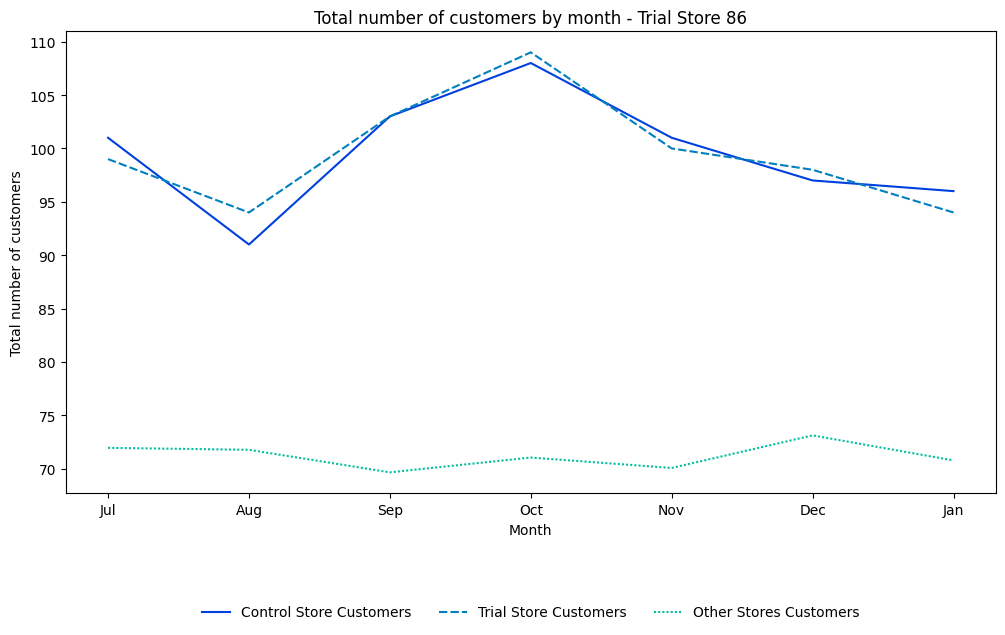

In [166]:
#Plot the monthly number of customers for trial store 86 and its control store.
plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month - Trial Store 86')
ax1_86 = sns.lineplot(data=combine_Customer_Plot_86, palette="winter")

plt.ylabel("Total number of customers")
sns.move_legend(
    ax1_86, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
    )

In [167]:
#Calculate the pre-trial sales totals for trial store 86 and its control store.
trial_sales_sum_86 = preTrialMeasures.loc[pastSales_86['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum_86 = preTrialMeasures.loc[pastSales_86['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales_86 = trial_sales_sum_86 / control_sales_sum_86
scalingFactorForControlSales_86

np.float64(0.9700651481287743)

In [168]:
#Scale the control store's sales to match trial store 86 during the pre-trial period.
scaledControlSales_86 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store_86].copy()
scaledControlSales_86['controlSales'] = scaledControlSales_86['Total Sales'] * scalingFactorForControlSales_86
scaledControlSales_86

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
1793,155,201807,924.60,101,1.217822,2.032520,3.698400,2018-07-01,896.922236
1794,155,201808,782.70,91,1.307692,1.924370,3.417904,2018-08-01,759.269991
1795,155,201809,1014.40,103,1.398058,2.013889,3.497931,2018-09-01,984.034086
1796,155,201810,963.80,108,1.259259,2.000000,3.543382,2018-10-01,934.948790
1797,155,201811,898.80,101,1.316832,2.030075,3.328889,2018-11-01,871.894555
1798,155,201812,849.80,97,1.237113,2.016667,3.511570,2018-12-01,824.361363
1799,155,201901,874.60,96,1.302083,2.016000,3.470635,2019-01-01,848.418979
1800,155,201902,891.20,95,1.315789,2.032000,3.508661,2019-02-01,864.522060
1801,155,201903,804.40,94,1.255319,2.033898,3.351667,2019-03-01,780.320405
1802,155,201904,844.60,99,1.212121,2.016667,3.490083,2019-04-01,819.317024


In [169]:
#Calculate the monthly percentage difference between trial store 86 and its scaled control.
percentageDiff_86 = scaledControlSales_86[['YEARMONTH','controlSales']]
percentageDiff_86.reset_index(drop = True, inplace = True)
trial_sales_86 = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store_86 , 'Total Sales']
trial_sales_86.reset_index(drop = True, inplace = True)

percentageDiff_86 = pd.concat([percentageDiff_86, trial_sales_86], axis = 1)
percentageDiff_86.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff_86['percentageDiff'] = abs(percentageDiff_86.controlSales - percentageDiff_86.Trial_Sales) / percentageDiff_86.controlSales
percentageDiff_86

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,896.922236,892.20,0.005265
1,201808,759.269991,764.05,0.006296
2,201809,984.034086,914.60,0.070561
3,201810,934.948790,948.40,0.014387
4,201811,871.894555,918.00,0.052880
5,201812,824.361363,841.20,0.020426
6,201901,848.418979,841.40,0.008273
7,201902,864.522060,913.20,0.056306
8,201903,780.320405,1026.80,0.315870
9,201904,819.317024,848.20,0.035253


In [170]:
#Calculate the pre-trial standard deviation of sales differences for trial store 86.
stdDev_86 = stdev(percentageDiff_86.loc[percentageDiff_86['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev_86

0.02583395285477237

In [171]:
#Calculate t-values and identify significant sales differences for trial store 86.
percentageDiff_86['tValue'] = (percentageDiff_86['percentageDiff'] - 0) / stdDev_86
percentageDiff_86.loc[(percentageDiff_86['YEARMONTH'] < 201905 ) & (percentageDiff_86['YEARMONTH'] > 201901), 'tValue']

7     2.179542
8    12.226922
9     1.364580
Name: tValue, dtype: float64

In [172]:
#Prepare trial store 86 sales data for the final trial-versus-control assessment.
pastSalesOnly_86 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store_86, ['TransactionMonth', 'Total Sales']]
pastSalesOnly_86.set_index('TransactionMonth', inplace = True)
pastSalesOnly_86.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)

controlSalesOnly_86 = scaledControlSales_86.loc[:, ['TransactionMonth', 'controlSales']]
controlSalesOnly_86.set_index('TransactionMonth', inplace = True)
controlSalesOnly_86.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)

controlSalesOnly_86['Control store 95th percentile'] = controlSalesOnly_86['Control Sales'] * (1 + stdDev_86*2)
controlSalesOnly_86['Control store 5th percentile'] = controlSalesOnly_86['Control Sales'] * (1 - stdDev_86*2)

trialAssessment_86 = pd.merge(controlSalesOnly_86, pastSalesOnly_86, left_index = True, right_index = True)
trialAssessment_86

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,896.922236,943.264329,850.580142,892.20
2018-08-01,759.269991,798.499882,720.040101,764.05
2018-09-01,984.034086,1034.877067,933.191106,914.60
2018-10-01,934.948790,983.255636,886.641944,948.40
2018-11-01,871.894555,916.943521,826.845589,918.00
2018-12-01,824.361363,866.954388,781.768338,841.20
2019-01-01,848.418979,892.255010,804.582947,841.40
2019-02-01,864.522060,909.190104,819.854016,913.20
2019-03-01,780.320405,820.637926,740.002884,1026.80


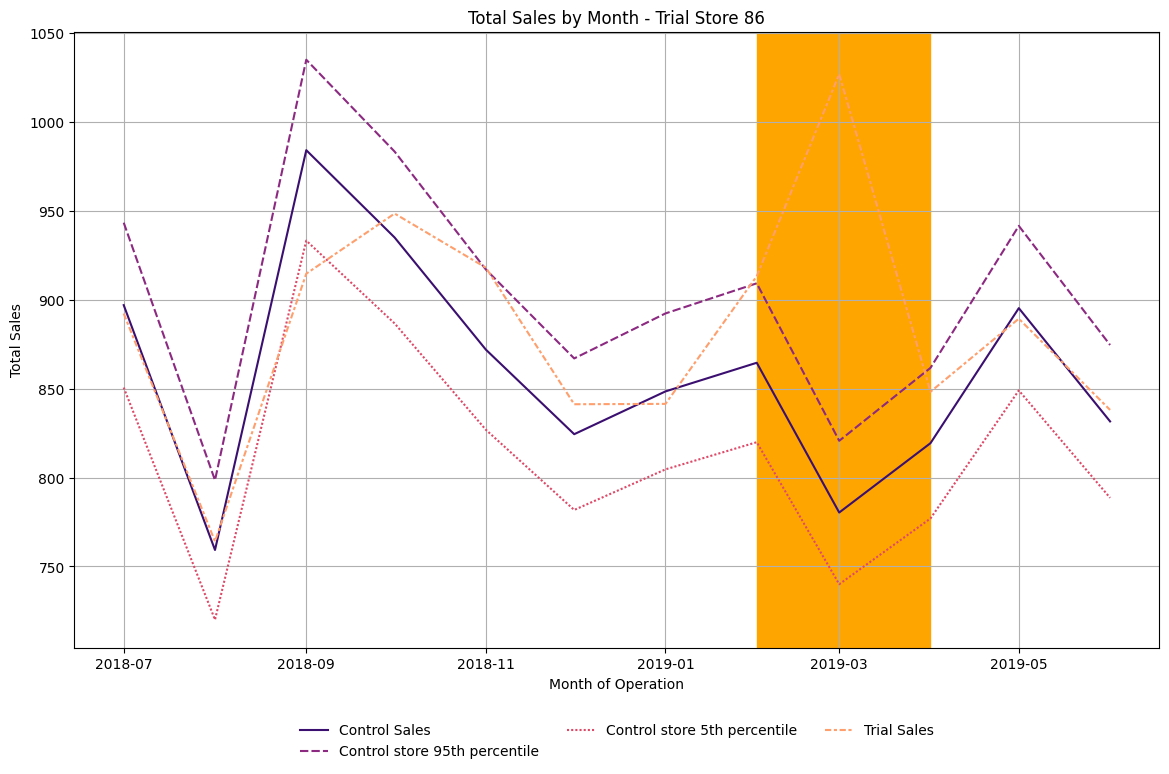

In [173]:
#Plot trial store 86 sales against scaled control sales and the confidence boundary.
plt.figure(figsize = (14,8))
ax2_86 = sns.lineplot(data=trialAssessment_86, palette = 'magma')

sns.move_legend(
    ax2_86, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Sales by Month - Trial Store 86')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')

plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

In [174]:
#Calculate the pre-trial customer totals for trial store 86 and its control store.
trial_customers_sum_86 = preTrialMeasures.loc[pastSales_86['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers_sum_86 = preTrialMeasures.loc[pastSales_86['store_type'] == 'Control Store' , 'no_Customers'].sum()
scalingFactorForControlCustomers_86 = trial_customers_sum_86 / control_customers_sum_86
scalingFactorForControlCustomers_86

np.float64(1.0)

In [175]:
#Scale the control store's customer counts to match trial store 86 before the trial.
scaledControlCustomers_86 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store_86].copy()
scaledControlCustomers_86['controlCustomers'] = scaledControlCustomers_86['no_Customers'] * scalingFactorForControlCustomers_86
scaledControlCustomers_86

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlCustomers
1793,155,201807,924.60,101,1.217822,2.032520,3.698400,2018-07-01,101.0
1794,155,201808,782.70,91,1.307692,1.924370,3.417904,2018-08-01,91.0
1795,155,201809,1014.40,103,1.398058,2.013889,3.497931,2018-09-01,103.0
1796,155,201810,963.80,108,1.259259,2.000000,3.543382,2018-10-01,108.0
1797,155,201811,898.80,101,1.316832,2.030075,3.328889,2018-11-01,101.0
1798,155,201812,849.80,97,1.237113,2.016667,3.511570,2018-12-01,97.0
1799,155,201901,874.60,96,1.302083,2.016000,3.470635,2019-01-01,96.0
1800,155,201902,891.20,95,1.315789,2.032000,3.508661,2019-02-01,95.0
1801,155,201903,804.40,94,1.255319,2.033898,3.351667,2019-03-01,94.0
1802,155,201904,844.60,99,1.212121,2.016667,3.490083,2019-04-01,99.0


In [176]:
#Calculate the monthly percentage difference between trial store 86 and its scaled control customers.
percentageDiffCustomers_86 = scaledControlCustomers_86[['YEARMONTH','controlCustomers']]
percentageDiffCustomers_86.reset_index(drop = True, inplace = True)
trial_customers_86 = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store_86 , 'no_Customers']
trial_customers_86.reset_index(drop = True, inplace = True)

percentageDiffCustomers_86 = pd.concat([percentageDiffCustomers_86, trial_customers_86], axis = 1)
percentageDiffCustomers_86.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiffCustomers_86['percentageDiff'] = abs(percentageDiffCustomers_86.controlCustomers - percentageDiffCustomers_86.Trial_Customers) / percentageDiffCustomers_86.controlCustomers
percentageDiffCustomers_86

,YEARMONTH,controlCustomers,Trial_Customers,percentageDiff
0,201807,101.0,99,0.019802
1,201808,91.0,94,0.032967
2,201809,103.0,103,0.000000
3,201810,108.0,109,0.009259
4,201811,101.0,100,0.009901
5,201812,97.0,98,0.010309
6,201901,96.0,94,0.020833
7,201902,95.0,107,0.126316
8,201903,94.0,115,0.223404
9,201904,99.0,105,0.060606


In [177]:
#Calculate the pre-trial standard deviation of customer differences for trial store 86.
stdDevCustomers_86 = stdev(percentageDiffCustomers_86.loc[percentageDiffCustomers_86['YEARMONTH'] < 201902, 'percentageDiff'])
stdDevCustomers_86

0.010687444701395236

In [178]:
#Calculate t-values and identify significant customer differences for trial store 86.
percentageDiffCustomers_86['tValue'] = (percentageDiffCustomers_86['percentageDiff'] - 0) / stdDevCustomers_86
percentageDiffCustomers_86.loc[(percentageDiffCustomers_86['YEARMONTH'] < 201905 ) & (percentageDiffCustomers_86['YEARMONTH'] > 201901), 'tValue']

7    11.819082
8    20.903430
9     5.670772
Name: tValue, dtype: float64

In [179]:
#Prepare trial store 86 customer data for the final trial-versus-control assessment.
trialCustomersOnly_86 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store_86, ['TransactionMonth', 'no_Customers']]
trialCustomersOnly_86.set_index('TransactionMonth', inplace = True)
trialCustomersOnly_86.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)

controlCustomersOnly_86 = scaledControlCustomers_86.loc[:, ['TransactionMonth', 'controlCustomers']]
controlCustomersOnly_86.set_index('TransactionMonth', inplace = True)
controlCustomersOnly_86.rename(columns = {'controlCustomers': 'Control Customers'}, inplace = True)

controlCustomersOnly_86['Control store 95th percentile'] = controlCustomersOnly_86['Control Customers'] * (1 + stdDevCustomers_86*2)
controlCustomersOnly_86['Control store 5th percentile'] = controlCustomersOnly_86['Control Customers'] * (1 - stdDevCustomers_86*2)

customerAssessment_86 = pd.merge(controlCustomersOnly_86, trialCustomersOnly_86, left_index = True, right_index = True)
customerAssessment_86

,Control Customers,Control store 95th percentile,Control store 5th percentile,Trial Customers
TransactionMonth,,,,
2018-07-01,101.0,103.158864,98.841136,99
2018-08-01,91.0,92.945115,89.054885,94
2018-09-01,103.0,105.201614,100.798386,103
2018-10-01,108.0,110.308488,105.691512,109
2018-11-01,101.0,103.158864,98.841136,100
2018-12-01,97.0,99.073364,94.926636,98
2019-01-01,96.0,98.051989,93.948011,94
2019-02-01,95.0,97.030614,92.969386,107
2019-03-01,94.0,96.009240,91.990760,115


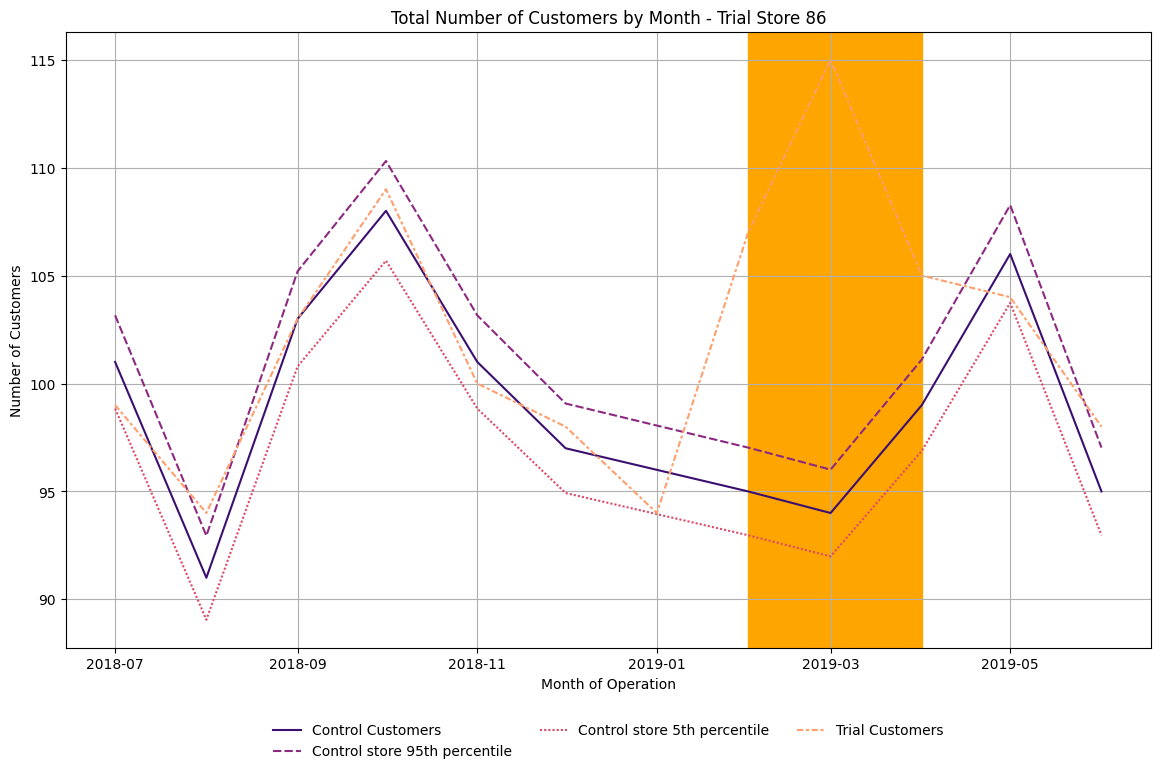

In [180]:
#Plot customer counts for trial store 86 against its scaled control and confidence boundary.
plt.figure(figsize = (14,8))
ax3_86 = sns.lineplot(data=customerAssessment_86, palette = 'magma')

sns.move_legend(
    ax3_86, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month - Trial Store 86')
plt.xlabel('Month of Operation')
plt.ylabel('Number of Customers')

plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

In [181]:
#Select trial store 88 and calculate sales and customer similarity scores.
trial_store_88 = 88
corr_Sales_88 = calculateCorrelation(preTrialMeasures, 'Total Sales', trial_store_88)
corr_Customers_88 = calculateCorrelation(preTrialMeasures, 'no_Customers', trial_store_88)

magnitude_Sales_88 = calculateMagnitudeDistance(preTrialMeasures, 'Total Sales', trial_store_88)
magnitude_Customers_88 = calculateMagnitudeDistance(preTrialMeasures, 'no_Customers', trial_store_88)

In [182]:
#Combine the sales and customer correlation and magnitude scores for trial store 88.
score_Sales_88 = pd.concat([corr_Sales_88, magnitude_Sales_88['Magnitude']], axis = 1)
score_Customers_88 = pd.concat([corr_Customers_88, magnitude_Customers_88['Magnitude']], axis = 1)

score_Sales_88['scoreSales'] = corr_weight * score_Sales_88['corr_measure'] + (1 - corr_weight) * score_Sales_88['Magnitude']
score_Customers_88['scoreCustomers'] = corr_weight * score_Customers_88['corr_measure'] + (1 - corr_weight) * score_Customers_88['Magnitude']

score_Sales_88 = score_Sales_88.reset_index().set_index(['Store1', 'Store2'])
score_Customers_88 = score_Customers_88.reset_index().set_index(['Store1', 'Store2'])

score_Control_88 = pd.concat([score_Sales_88['scoreSales'], score_Customers_88['scoreCustomers']], axis=1)
score_Control_88['finalControlScore'] = 0.5 * score_Control_88['scoreSales'] + 0.5 * score_Control_88['scoreCustomers']

control_store_88_candidates = score_Control_88.reset_index()
control_store_88_candidates = control_store_88_candidates[
    control_store_88_candidates['Store2'] != trial_store_88
].sort_values(by='finalControlScore', ascending=False)

control_store_88_candidates.head()

,Store1,Store2,scoreSales,scoreCustomers,finalControlScore
170,88,178,0.650803,0.707828,0.679316
12,88,14,0.646064,0.685774,0.665919
126,88,134,0.775084,0.540154,0.657619
225,88,237,0.451974,0.777235,0.614604
179,88,187,0.616752,0.594560,0.605656


In [183]:
#Select the best matching control store for trial store 88.
control_store_88 = int(control_store_88_candidates.iloc[0]['Store2'])
control_store_88

178

In [184]:
#Classify stores for the trial-store-88 analysis and prepare the historical data.
pastSales_88 = preTrialMeasures.copy()
store_type_88 = []
for i in pastSales_88['STORE_NBR']:
    if i == trial_store_88:
        store_type_88.append('Trial Store')
    elif i == control_store_88:
        store_type_88.append('Control Store')
    else:
        store_type_88.append('Other Stores')

pastSales_88['store_type'] = store_type_88
pastSales_88['TransactionMonth'] = pd.to_datetime(pastSales_88['YEARMONTH'].astype(str), format = '%Y%m')
pastSales_88['Month'] = pd.DatetimeIndex(pastSales_88['TransactionMonth']).month_name().str[:3]
pastSales_88.head()

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,store_type,Month
0,1,201807,206.9,49,1.061224,1.192308,3.337097,2018-07-01,Other Stores,Jul
1,1,201808,176.1,42,1.023810,1.255814,3.261111,2018-08-01,Other Stores,Aug
2,1,201809,278.8,59,1.050847,1.209677,3.717333,2018-09-01,Other Stores,Sep
3,1,201810,188.1,44,1.022727,1.288889,3.243103,2018-10-01,Other Stores,Oct
4,1,201811,192.6,46,1.021739,1.212766,3.378947,2018-11-01,Other Stores,Nov


In [185]:
#Prepare monthly sales data for the control store matched to trial store 88.
controlPlot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Control Store', ['Month', 'Total Sales']]
controlPlot_88.set_index('Month', inplace = True)

trialPlot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Trial Store', ['Month', 'Total Sales']]
trialPlot_88.set_index('Month', inplace = True)

otherPlot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Other Stores', ['Month', 'Total Sales']]
otherPlot_88 = pd.DataFrame(otherPlot_88.groupby('Month')['Total Sales'].mean())

controlPlot_88.rename(columns = {'Total Sales': 'Control Store Sales'}, inplace = True)
trialPlot_88.rename(columns = {'Total Sales': 'Trial Store Sales'}, inplace = True)
otherPlot_88.rename(columns = {'Total Sales': 'Other Stores Sales'}, inplace = True)

combinePlot_88 = pd.concat([controlPlot_88, trialPlot_88, otherPlot_88], axis = 1)
combinePlot_88

,Control Store Sales,Trial Store Sales,Other Stores Sales
Month,,,
Jul,952.0,1310.0,631.514341
Aug,915.5,1323.8,603.642442
Sep,954.4,1423.0,612.742636
Oct,962.6,1352.4,627.854264
Nov,975.6,1382.8,611.494186
Dec,947.2,1325.2,641.766667
Jan,837.2,1266.4,622.011240


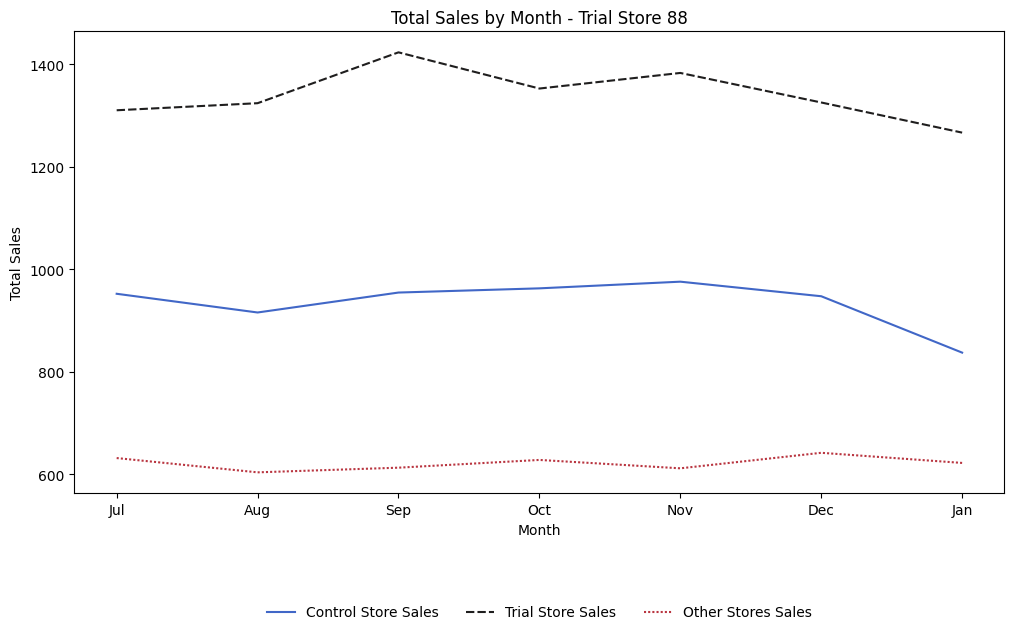

In [186]:
#Plot monthly sales for trial store 88 and its selected control store.
plt.figure(figsize = (12, 6))
plt.title('Total Sales by Month - Trial Store 88')
ax_88 = sns.lineplot(data=combinePlot_88, palette="icefire")

plt.ylabel("Total Sales")
sns.move_legend(
    ax_88, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

In [187]:
#Prepare monthly customer data for the control store matched to trial store 88.
control_Customer_Plot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Control Store', ['Month', 'no_Customers']]
control_Customer_Plot_88.set_index('Month', inplace = True)

trial_Customer_Plot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Trial Store', ['Month', 'no_Customers']]
trial_Customer_Plot_88.set_index('Month', inplace = True)

other_Customer_Plot_88 = pastSales_88.loc[pastSales_88['store_type'] == 'Other Stores', ['Month', 'no_Customers']]
other_Customer_Plot_88 = pd.DataFrame(other_Customer_Plot_88.groupby('Month')['no_Customers'].mean())

control_Customer_Plot_88.rename(columns = {'no_Customers': 'Control Store Customers'}, inplace = True)
trial_Customer_Plot_88.rename(columns = {'no_Customers': 'Trial Store Customers'}, inplace = True)
other_Customer_Plot_88.rename(columns = {'no_Customers': 'Other Stores Customers'}, inplace = True)

combine_Customer_Plot_88 = pd.concat([control_Customer_Plot_88, trial_Customer_Plot_88, other_Customer_Plot_88], axis = 1)
combine_Customer_Plot_88

,Control Store Customers,Trial Store Customers,Other Stores Customers
Month,,,
Jul,107,129,71.813953
Aug,108,131,71.562016
Sep,101,124,69.585271
Oct,102,123,71.015504
Nov,111,130,69.914729
Dec,101,126,72.996124
Jan,95,117,70.689922


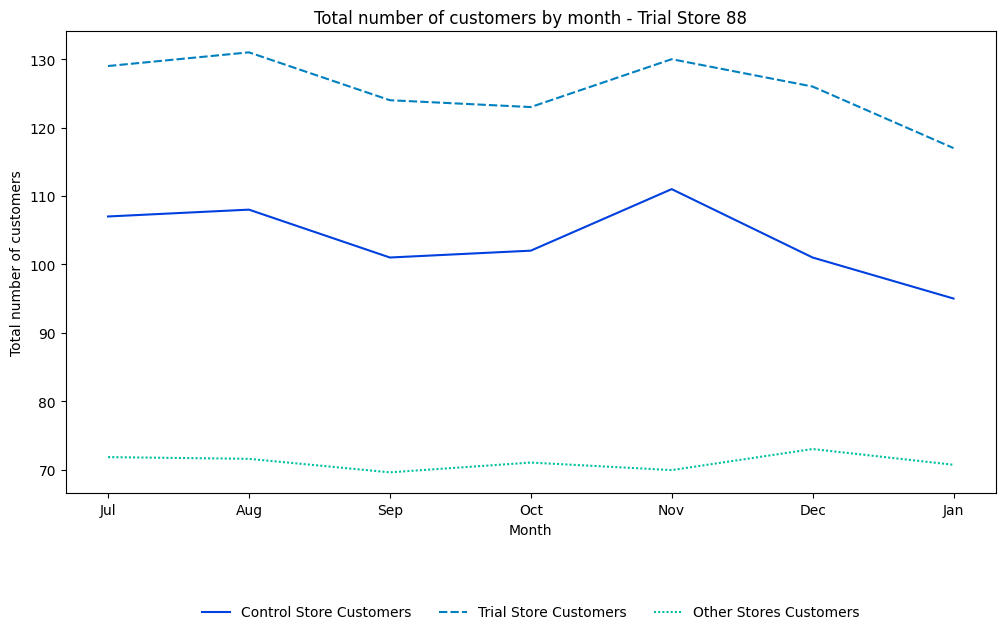

In [188]:
#Plot the monthly number of customers for trial store 88 and its control store.
plt.figure(figsize = (12, 6))
plt.title('Total number of customers by month - Trial Store 88')
ax1_88 = sns.lineplot(data=combine_Customer_Plot_88, palette="winter")

plt.ylabel("Total number of customers")
sns.move_legend(
    ax1_88, "lower center",
    bbox_to_anchor=(0.5, -.3),
    ncol=3,
    frameon=False,
)

In [189]:
#Calculate the pre-trial sales totals for trial store 88 and its control store.
trial_sales_sum_88 = preTrialMeasures.loc[pastSales_88['store_type'] == 'Trial Store' , 'Total Sales'].sum()
control_sales_sum_88 = preTrialMeasures.loc[pastSales_88['store_type'] == 'Control Store' , 'Total Sales'].sum()
scalingFactorForControlSales_88 = trial_sales_sum_88 / control_sales_sum_88
scalingFactorForControlSales_88

np.float64(1.4338146535258616)

In [190]:
#Scale the control store's sales to match trial store 88 during the pre-trial period.
scaledControlSales_88 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store_88].copy()
scaledControlSales_88['controlSales'] = scaledControlSales_88['Total Sales'] * scalingFactorForControlSales_88
scaledControlSales_88

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlSales
2069,178,201807,952.0,107,1.224299,2.015267,3.606061,2018-07-01,1364.991550
2070,178,201808,915.5,108,1.231481,1.902256,3.618577,2018-08-01,1312.657315
2071,178,201809,954.4,101,1.267327,2.078125,3.587970,2018-09-01,1368.432705
2072,178,201810,962.6,102,1.382353,2.056738,3.319310,2018-10-01,1380.189985
2073,178,201811,975.6,111,1.243243,2.014493,3.509353,2018-11-01,1398.829576
2074,178,201812,947.2,101,1.326733,2.014925,3.508148,2018-12-01,1358.109240
2075,178,201901,837.2,95,1.242105,2.067797,3.431148,2019-01-01,1200.389628
2076,178,201902,1088.8,107,1.355140,2.027586,3.703401,2019-02-01,1561.137395
2077,178,201903,998.8,114,1.254386,2.000000,3.492308,2019-03-01,1432.094076
2078,178,201904,1059.8,117,1.264957,2.027027,3.532667,2019-04-01,1519.556770


In [191]:
#Calculate the monthly percentage difference between trial store 88 and its scaled control.
percentageDiff_88 = scaledControlSales_88[['YEARMONTH','controlSales']]
percentageDiff_88.reset_index(drop = True, inplace = True)
trial_sales_88 = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store_88 , 'Total Sales']
trial_sales_88.reset_index(drop = True, inplace = True)

percentageDiff_88 = pd.concat([percentageDiff_88, trial_sales_88], axis = 1)
percentageDiff_88.rename(columns = {'Total Sales': 'Trial_Sales'}, inplace = True)
percentageDiff_88['percentageDiff'] = abs(percentageDiff_88.controlSales - percentageDiff_88.Trial_Sales) / percentageDiff_88.controlSales
percentageDiff_88

,YEARMONTH,controlSales,Trial_Sales,percentageDiff
0,201807,1364.991550,1310.00,0.040287
1,201808,1312.657315,1323.80,0.008489
2,201809,1368.432705,1423.00,0.039876
3,201810,1380.189985,1352.40,0.020135
4,201811,1398.829576,1382.80,0.011459
5,201812,1358.109240,1325.20,0.024232
6,201901,1200.389628,1266.40,0.054991
7,201902,1561.137395,1370.20,0.122307
8,201903,1432.094076,1477.20,0.031496
9,201904,1519.556770,1439.40,0.052750


In [192]:
#Calculate the pre-trial standard deviation of sales differences for trial store 88.
stdDev_88 = stdev(percentageDiff_88.loc[percentageDiff_88['YEARMONTH'] < 201902, 'percentageDiff'])
stdDev_88

0.017074051922797567

In [193]:
#Calculate t-values and identify significant sales differences for trial store 88.
percentageDiff_88['tValue'] = (percentageDiff_88['percentageDiff'] - 0) / stdDev_88
percentageDiff_88.loc[(percentageDiff_88['YEARMONTH'] < 201905 ) & (percentageDiff_88['YEARMONTH'] > 201901), 'tValue']

7    7.163302
8    1.844699
9    3.089489
Name: tValue, dtype: float64

In [194]:
#Prepare trial store 88 sales data for the final trial-versus-control assessment.
pastSalesOnly_88 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store_88, ['TransactionMonth', 'Total Sales']]
pastSalesOnly_88.set_index('TransactionMonth', inplace = True)
pastSalesOnly_88.rename(columns = {'Total Sales': 'Trial Sales'}, inplace = True)

controlSalesOnly_88 = scaledControlSales_88.loc[:, ['TransactionMonth', 'controlSales']]
controlSalesOnly_88.set_index('TransactionMonth', inplace = True)
controlSalesOnly_88.rename(columns = {'controlSales': 'Control Sales'}, inplace = True)

controlSalesOnly_88['Control store 95th percentile'] = controlSalesOnly_88['Control Sales'] * (1 + stdDev_88*2)
controlSalesOnly_88['Control store 5th percentile'] = controlSalesOnly_88['Control Sales'] * (1 - stdDev_88*2)

trialAssessment_88 = pd.merge(controlSalesOnly_88, pastSalesOnly_88, left_index = True, right_index = True)
trialAssessment_88

,Control Sales,Control store 95th percentile,Control store 5th percentile,Trial Sales
TransactionMonth,,,,
2018-07-01,1364.991550,1411.603423,1318.379677,1310.00
2018-08-01,1312.657315,1357.482074,1267.832557,1323.80
2018-09-01,1368.432705,1415.162087,1321.703323,1423.00
2018-10-01,1380.189985,1427.320856,1333.059115,1352.40
2018-11-01,1398.829576,1446.596954,1351.062198,1382.80
2018-12-01,1358.109240,1404.486095,1311.732384,1325.20
2019-01-01,1200.389628,1241.380658,1159.398598,1266.40
2019-02-01,1561.137395,1614.447277,1507.827513,1370.20
2019-03-01,1432.094076,1480.997373,1383.190779,1477.20


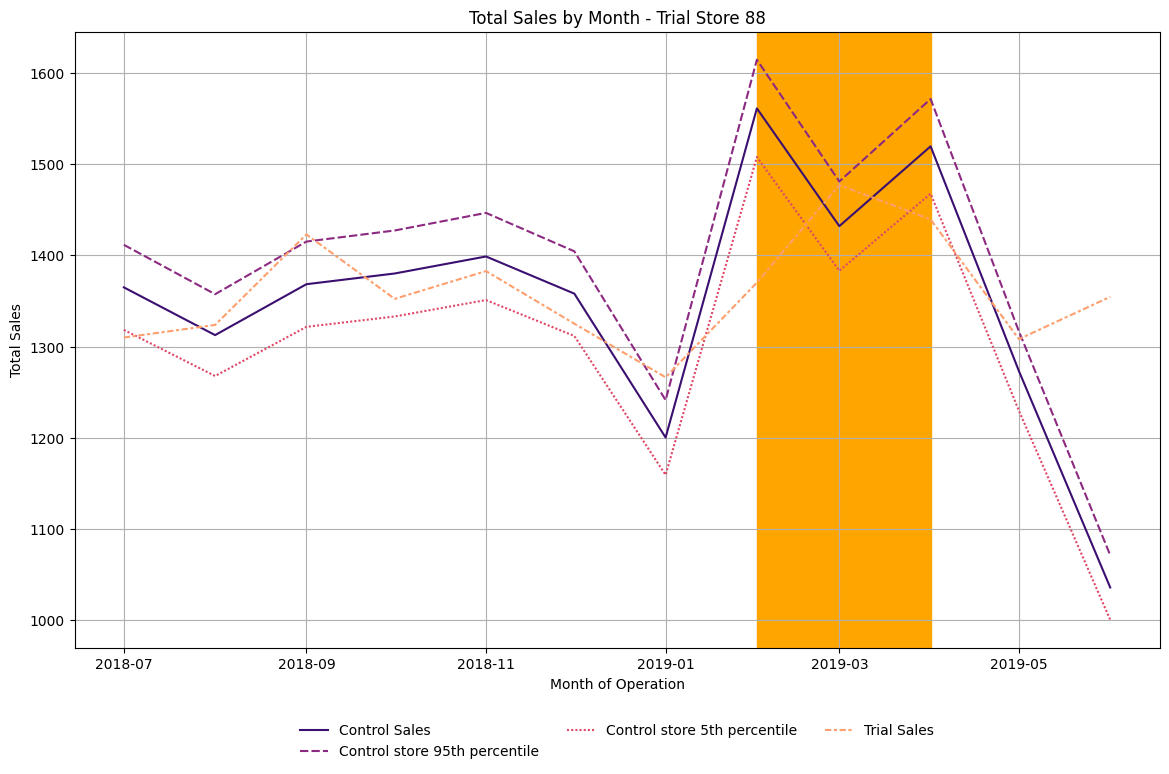

In [195]:
#Plot trial store 88 sales against scaled control sales and the confidence boundary.
plt.figure(figsize = (14,8))
ax2_88 = sns.lineplot(data=trialAssessment_88, palette = 'magma')

sns.move_legend(
    ax2_88, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Sales by Month - Trial Store 88')
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')

plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()

In [196]:
#Calculate the pre-trial customer totals for trial store 88 and its control store.
trial_customers_sum_88 = preTrialMeasures.loc[pastSales_88['store_type'] == 'Trial Store' , 'no_Customers'].sum()
control_customers_sum_88 = preTrialMeasures.loc[pastSales_88['store_type'] == 'Control Store' , 'no_Customers'].sum()
scalingFactorForControlCustomers_88 = trial_customers_sum_88 / control_customers_sum_88
scalingFactorForControlCustomers_88

np.float64(1.2137931034482758)

In [197]:
#Scale the control store's customer counts to match trial store 88 before the trial.
scaledControlCustomers_88 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == control_store_88].copy()
scaledControlCustomers_88['controlCustomers'] = scaledControlCustomers_88['no_Customers'] * scalingFactorForControlCustomers_88
scaledControlCustomers_88

,STORE_NBR,YEARMONTH,Total Sales,no_Customers,trans_per_customer,chips_per_customer,average_price,TransactionMonth,controlCustomers
2069,178,201807,952.0,107,1.224299,2.015267,3.606061,2018-07-01,129.875862
2070,178,201808,915.5,108,1.231481,1.902256,3.618577,2018-08-01,131.089655
2071,178,201809,954.4,101,1.267327,2.078125,3.587970,2018-09-01,122.593103
2072,178,201810,962.6,102,1.382353,2.056738,3.319310,2018-10-01,123.806897
2073,178,201811,975.6,111,1.243243,2.014493,3.509353,2018-11-01,134.731034
2074,178,201812,947.2,101,1.326733,2.014925,3.508148,2018-12-01,122.593103
2075,178,201901,837.2,95,1.242105,2.067797,3.431148,2019-01-01,115.310345
2076,178,201902,1088.8,107,1.355140,2.027586,3.703401,2019-02-01,129.875862
2077,178,201903,998.8,114,1.254386,2.000000,3.492308,2019-03-01,138.372414
2078,178,201904,1059.8,117,1.264957,2.027027,3.532667,2019-04-01,142.013793


In [198]:
#Calculate the monthly percentage difference between trial store 88 and its scaled control customers.
percentageDiffCustomers_88 = scaledControlCustomers_88[['YEARMONTH','controlCustomers']]
percentageDiffCustomers_88.reset_index(drop = True, inplace = True)
trial_customers_88 = measureOverTime.loc[measureOverTime['STORE_NBR'] == trial_store_88 , 'no_Customers']
trial_customers_88.reset_index(drop = True, inplace = True)

percentageDiffCustomers_88 = pd.concat([percentageDiffCustomers_88, trial_customers_88], axis = 1)
percentageDiffCustomers_88.rename(columns = {'no_Customers': 'Trial_Customers'}, inplace = True)
percentageDiffCustomers_88['percentageDiff'] = abs(percentageDiffCustomers_88.controlCustomers - percentageDiffCustomers_88.Trial_Customers) / percentageDiffCustomers_88.controlCustomers
percentageDiffCustomers_88

,YEARMONTH,controlCustomers,Trial_Customers,percentageDiff
0,201807,129.875862,129,0.006744
1,201808,131.089655,131,0.000684
2,201809,122.593103,124,0.011476
3,201810,123.806897,123,0.006517
4,201811,134.731034,130,0.035115
5,201812,122.593103,126,0.027790
6,201901,115.310345,117,0.014653
7,201902,129.875862,124,0.045242
8,201903,138.372414,134,0.031599
9,201904,142.013793,128,0.098679


In [199]:
#Calculate the pre-trial standard deviation of customer differences for trial store 88.
stdDevCustomers_88 = stdev(percentageDiffCustomers_88.loc[percentageDiffCustomers_88['YEARMONTH'] < 201902, 'percentageDiff'])
stdDevCustomers_88

0.012417826272588403

In [200]:
#Calculate t-values and identify significant customer differences for trial store 88.
percentageDiffCustomers_88['tValue'] = (percentageDiffCustomers_88['percentageDiff'] - 0) / stdDevCustomers_88
percentageDiffCustomers_88.loc[(percentageDiffCustomers_88['YEARMONTH'] < 201905 ) & (percentageDiffCustomers_88['YEARMONTH'] > 201901), 'tValue']

7    3.643322
8    2.544639
9    7.946568
Name: tValue, dtype: float64

In [201]:
#Prepare trial store 88 customer data for the final trial-versus-control assessment.
trialCustomersOnly_88 = measureOverTimeSales.loc[measureOverTimeSales['STORE_NBR'] == trial_store_88, ['TransactionMonth', 'no_Customers']]
trialCustomersOnly_88.set_index('TransactionMonth', inplace = True)
trialCustomersOnly_88.rename(columns = {'no_Customers': 'Trial Customers'}, inplace = True)

controlCustomersOnly_88 = scaledControlCustomers_88.loc[:, ['TransactionMonth', 'controlCustomers']]
controlCustomersOnly_88.set_index('TransactionMonth', inplace = True)
controlCustomersOnly_88.rename(columns = {'controlCustomers': 'Control Customers'}, inplace = True)

controlCustomersOnly_88['Control store 95th percentile'] = controlCustomersOnly_88['Control Customers'] * (1 + stdDevCustomers_88*2)
controlCustomersOnly_88['Control store 5th percentile'] = controlCustomersOnly_88['Control Customers'] * (1 - stdDevCustomers_88*2)

customerAssessment_88 = pd.merge(controlCustomersOnly_88, trialCustomersOnly_88, left_index = True, right_index = True)
customerAssessment_88

,Control Customers,Control store 95th percentile,Control store 5th percentile,Trial Customers
TransactionMonth,,,,
2018-07-01,129.875862,133.101414,126.650310,129
2018-08-01,131.089655,134.345352,127.833958,131
2018-09-01,122.593103,125.637783,119.548424,124
2018-10-01,123.806897,126.881722,120.732071,123
2018-11-01,134.731034,138.077168,131.384901,130
2018-12-01,122.593103,125.637783,119.548424,126
2019-01-01,115.310345,118.174152,112.446537,117
2019-02-01,129.875862,133.101414,126.650310,124
2019-03-01,138.372414,141.808983,134.935845,134


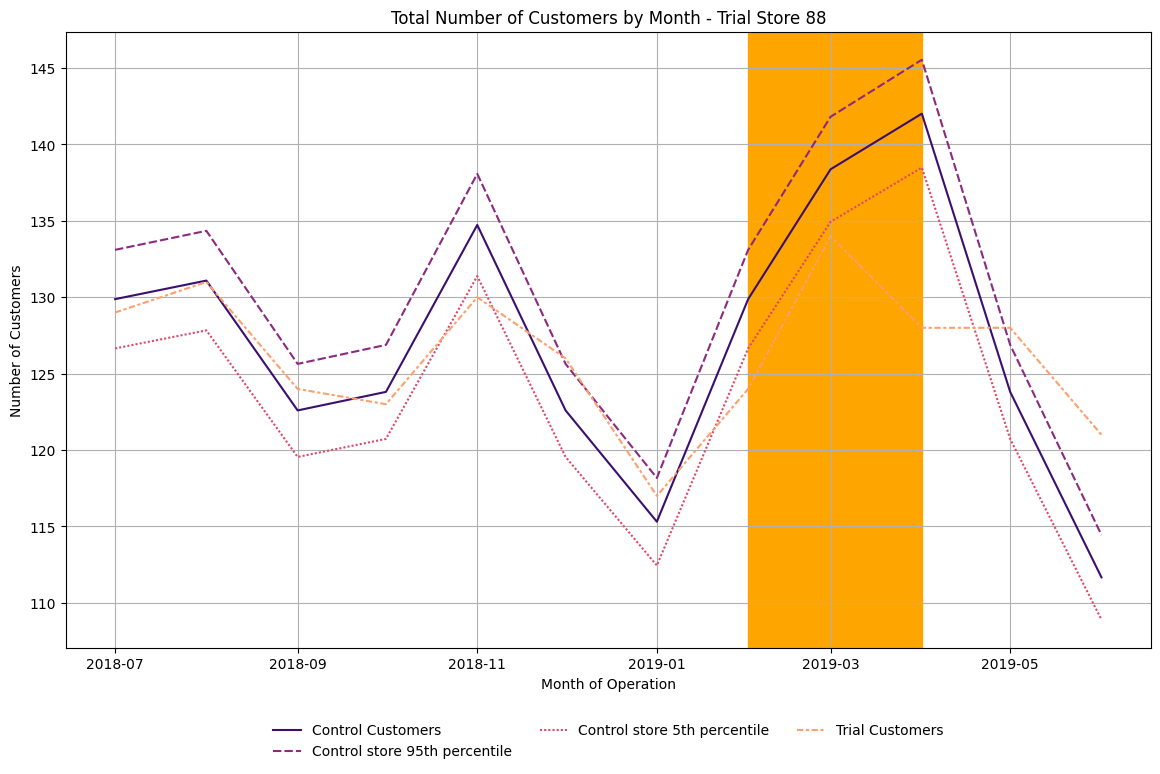

In [202]:
#Plot customer counts for trial store 88 against its scaled control and confidence boundary
plt.figure(figsize = (14,8))
ax3_88 = sns.lineplot(data=customerAssessment_88, palette = 'magma')

sns.move_legend(
    ax3_88, "lower center",
    bbox_to_anchor=(0.5, -.2),
    ncol=3,
    frameon=False,
)

plt.title('Total Number of Customers by Month - Trial Store 88')
plt.xlabel('Month of Operation')
plt.ylabel('Number of Customers')

plt.axvspan(*mdates.datestr2num(['2019-02-01', '2019-04-01']), color = 'orange', alpha = 1)
plt.grid()